In [17]:
import pandas as pd
import matplotlib.pyplot as plt

pd.options.mode.chained_assignment = None

data = pd.read_csv("precipitation-data-2026.csv")
data["date"] = pd.to_datetime(data["date"])
data = data.query("date < '2026-09-01'")

## Data Preprocessing

Before predicting precipitation trends for August using rainfall data from January to July of this year, it is important that the data is cleaned properly: in other words, the elimination or reduction of outliers and the imputing of missing rainfall data. Given that rainfall data is time-series data, the following steps will need to be applied so that any given regression model can return accurate predictions on future rainfall data

### Steps
1. Eliminate NaNs
2. Reduce impact of noise in data
3. Significantly reduce outliers

In [18]:
from sklearn.impute import KNNImputer
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import Pipeline

scaler = RobustScaler()
imputer = KNNImputer(n_neighbors=3, weights="uniform")

station_data = {}

for station in data['name'].unique():
    train = data.query("date < '2026-08-01' and name == '{}'".format(station))
    test = data.query("date <= '2026-08-31' and date >= '2026-08-01' and name == '{}'".format(station))

    pipeline = Pipeline([
        ('imputer', imputer),
        ('scaler', scaler)
    ])

    train[['rainfall']] = pipeline.fit_transform(train[['rainfall']])
    test[['rainfall']] = pipeline.transform(test[['rainfall']])
    
    station_data |= {station : [train, test]}

print(station_data)

{'RG_001': [           id    name                date  rainfall  longitude  latitude
0        7677  RG_001 2026-01-01 00:00:00       0.0 -79.478112  43.64768
1        7677  RG_001 2026-01-01 00:05:00       0.0 -79.478112  43.64768
2        7677  RG_001 2026-01-01 00:10:00       0.0 -79.478112  43.64768
3        7677  RG_001 2026-01-01 00:15:00       0.0 -79.478112  43.64768
4        7677  RG_001 2026-01-01 00:20:00       0.0 -79.478112  43.64768
...       ...     ...                 ...       ...        ...       ...
2943707  7677  RG_001 2026-07-31 23:35:00       0.0 -79.478112  43.64768
2943708  7677  RG_001 2026-07-31 23:40:00       0.0 -79.478112  43.64768
2943709  7677  RG_001 2026-07-31 23:45:00       0.0 -79.478112  43.64768
2943710  7677  RG_001 2026-07-31 23:50:00       0.0 -79.478112  43.64768
2943711  7677  RG_001 2026-07-31 23:55:00       0.0 -79.478112  43.64768

[60206 rows x 6 columns],            id    name                date  rainfall  longitude  latitude
2943712  767

## Post-Processed Charts

[[<Axes: title={'center': 'Rainfall - RG_001'}>
  <Axes: title={'center': 'Rainfall - RG_003'}>
  <Axes: title={'center': 'Rainfall - RG_004'}>
  <Axes: title={'center': 'Rainfall - RG_006'}>
  <Axes: title={'center': 'Rainfall - RG_007'}>]
 [<Axes: title={'center': 'Rainfall - RG_012'}>
  <Axes: title={'center': 'Rainfall - RG_013'}>
  <Axes: title={'center': 'Rainfall - RG_014'}>
  <Axes: title={'center': 'Rainfall - RG_015'}>
  <Axes: title={'center': 'Rainfall - RG_016'}>]
 [<Axes: title={'center': 'Rainfall - RG_017'}>
  <Axes: title={'center': 'Rainfall - RG_018'}>
  <Axes: title={'center': 'Rainfall - RG_019'}>
  <Axes: title={'center': 'Rainfall - RG_020'}>
  <Axes: title={'center': 'Rainfall - RG_021'}>]
 [<Axes: title={'center': 'Rainfall - RG_022'}>
  <Axes: title={'center': 'Rainfall - RG_023'}>
  <Axes: title={'center': 'Rainfall - RG_024'}>
  <Axes: title={'center': 'Rainfall - RG_025'}>
  <Axes: title={'center': 'Rainfall - RG_027'}>]
 [<Axes: title={'center': 'Rainfall 

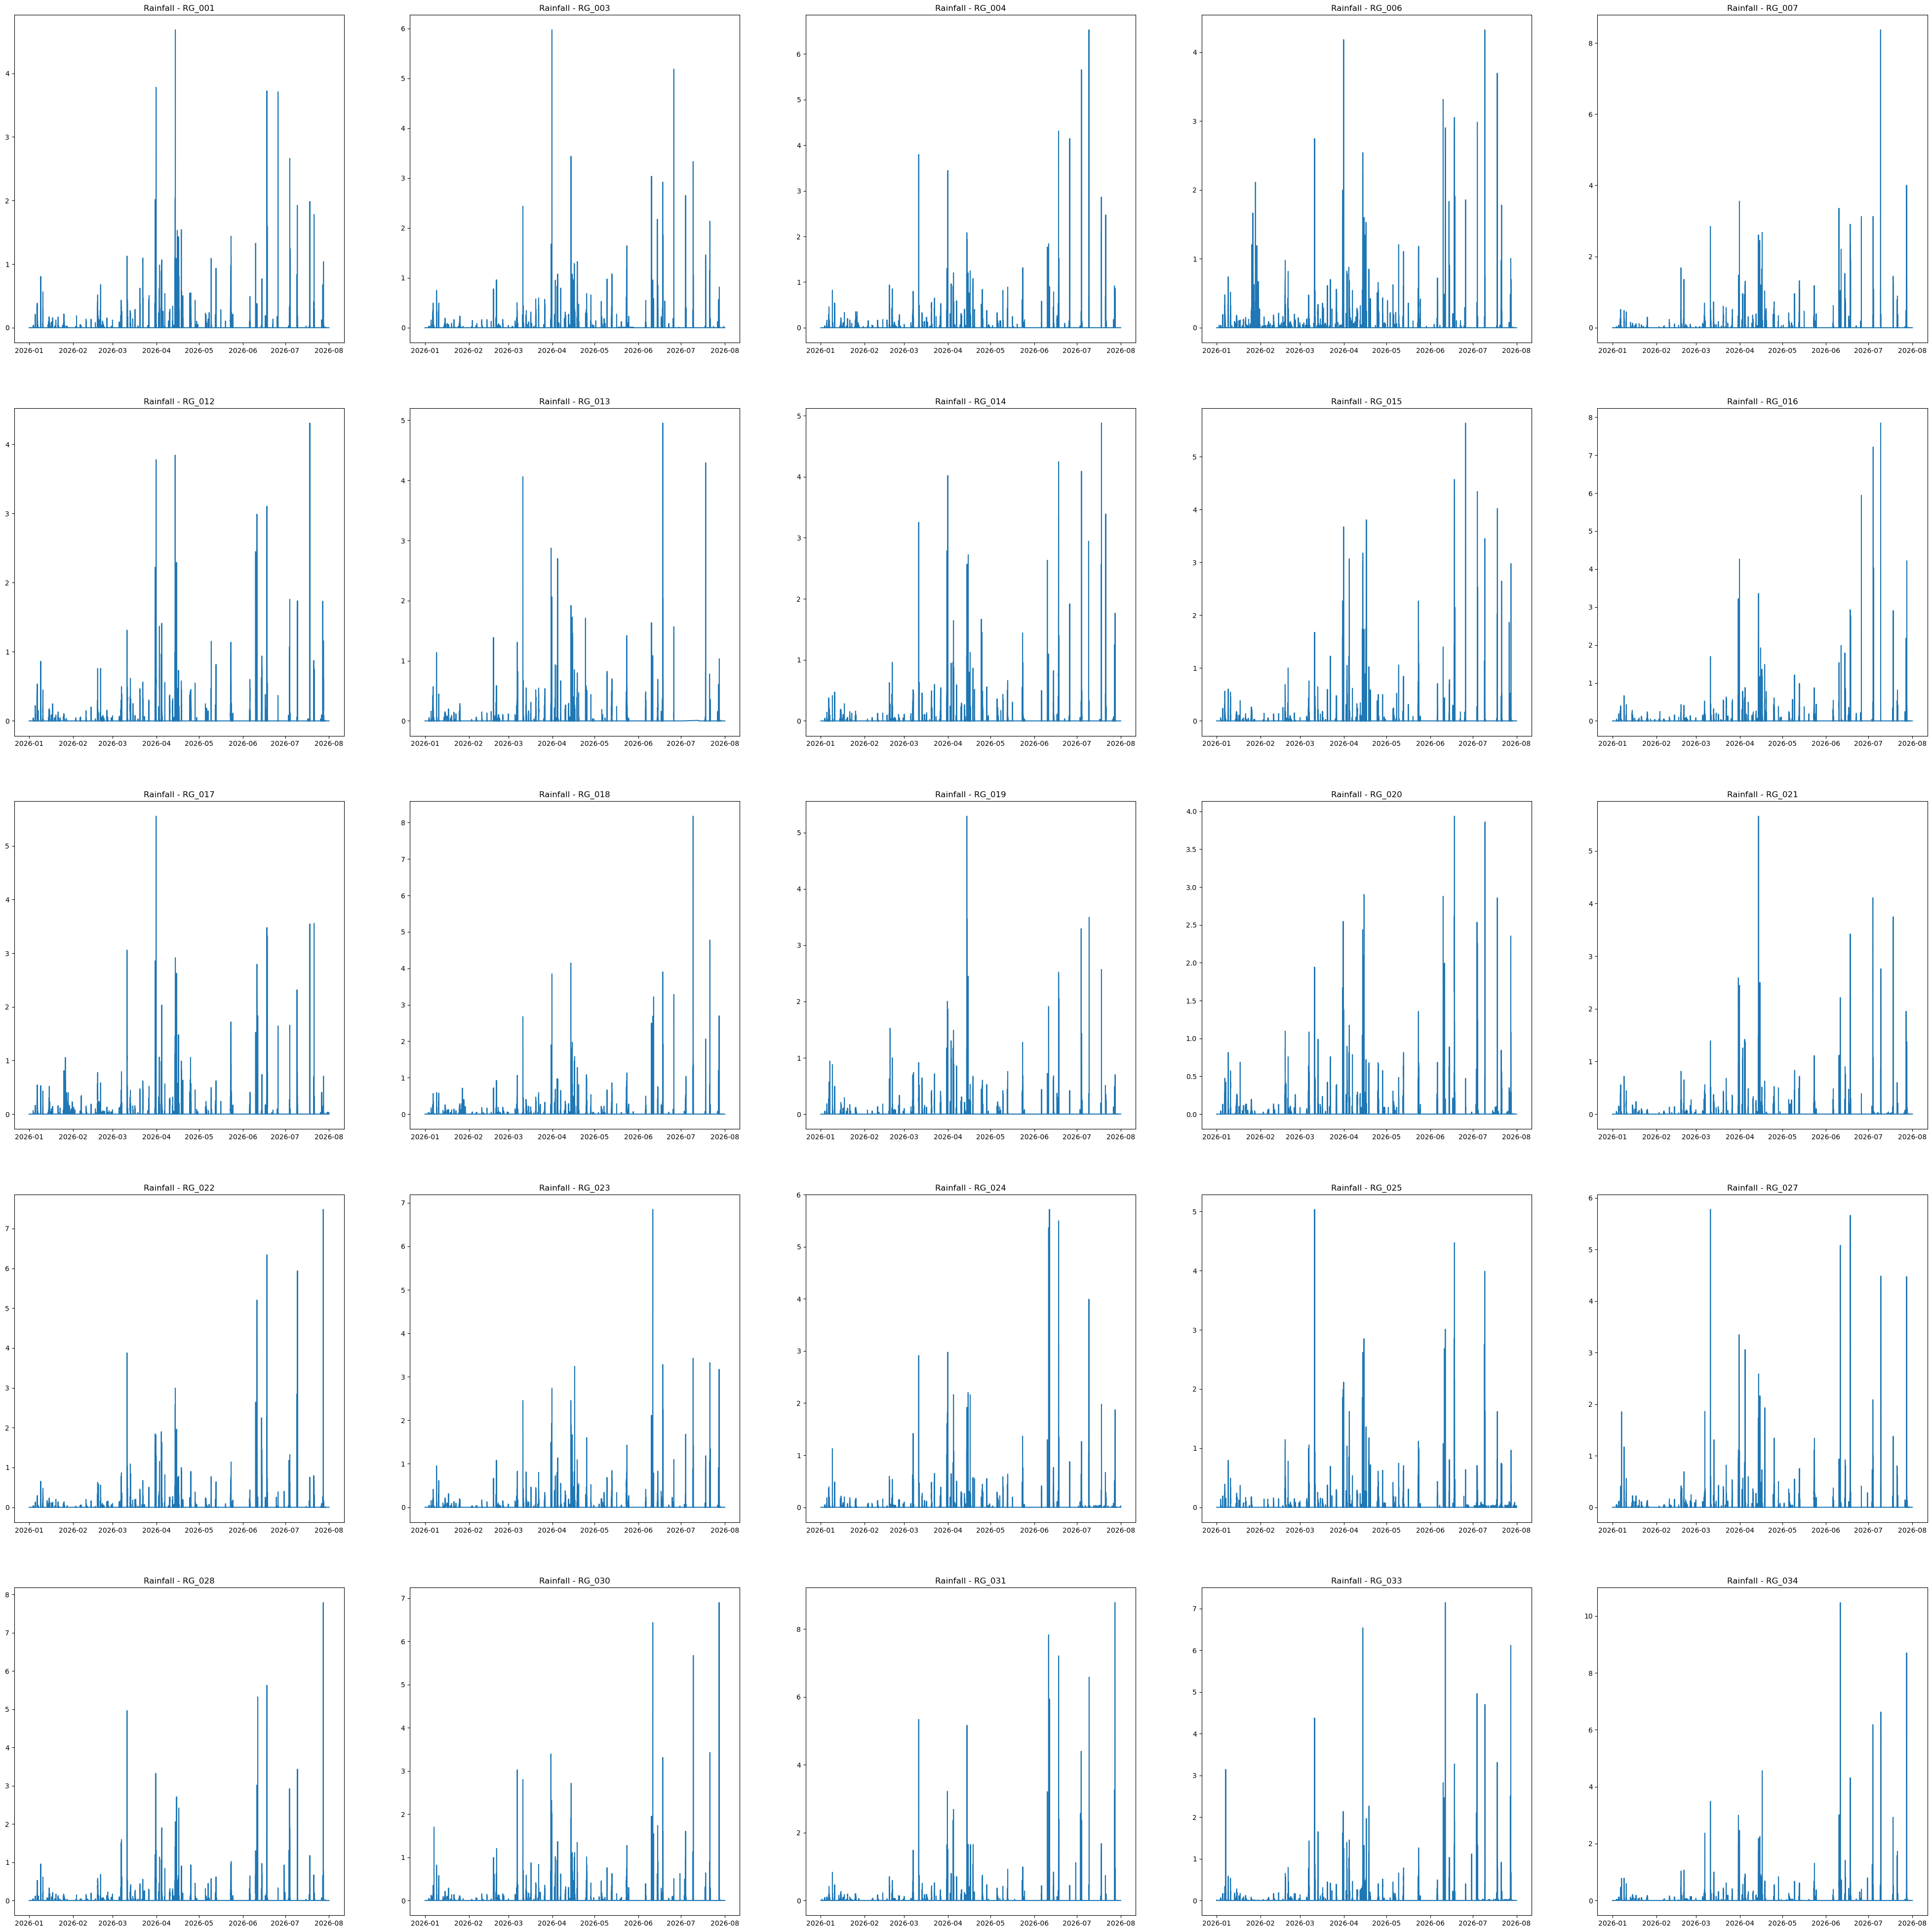

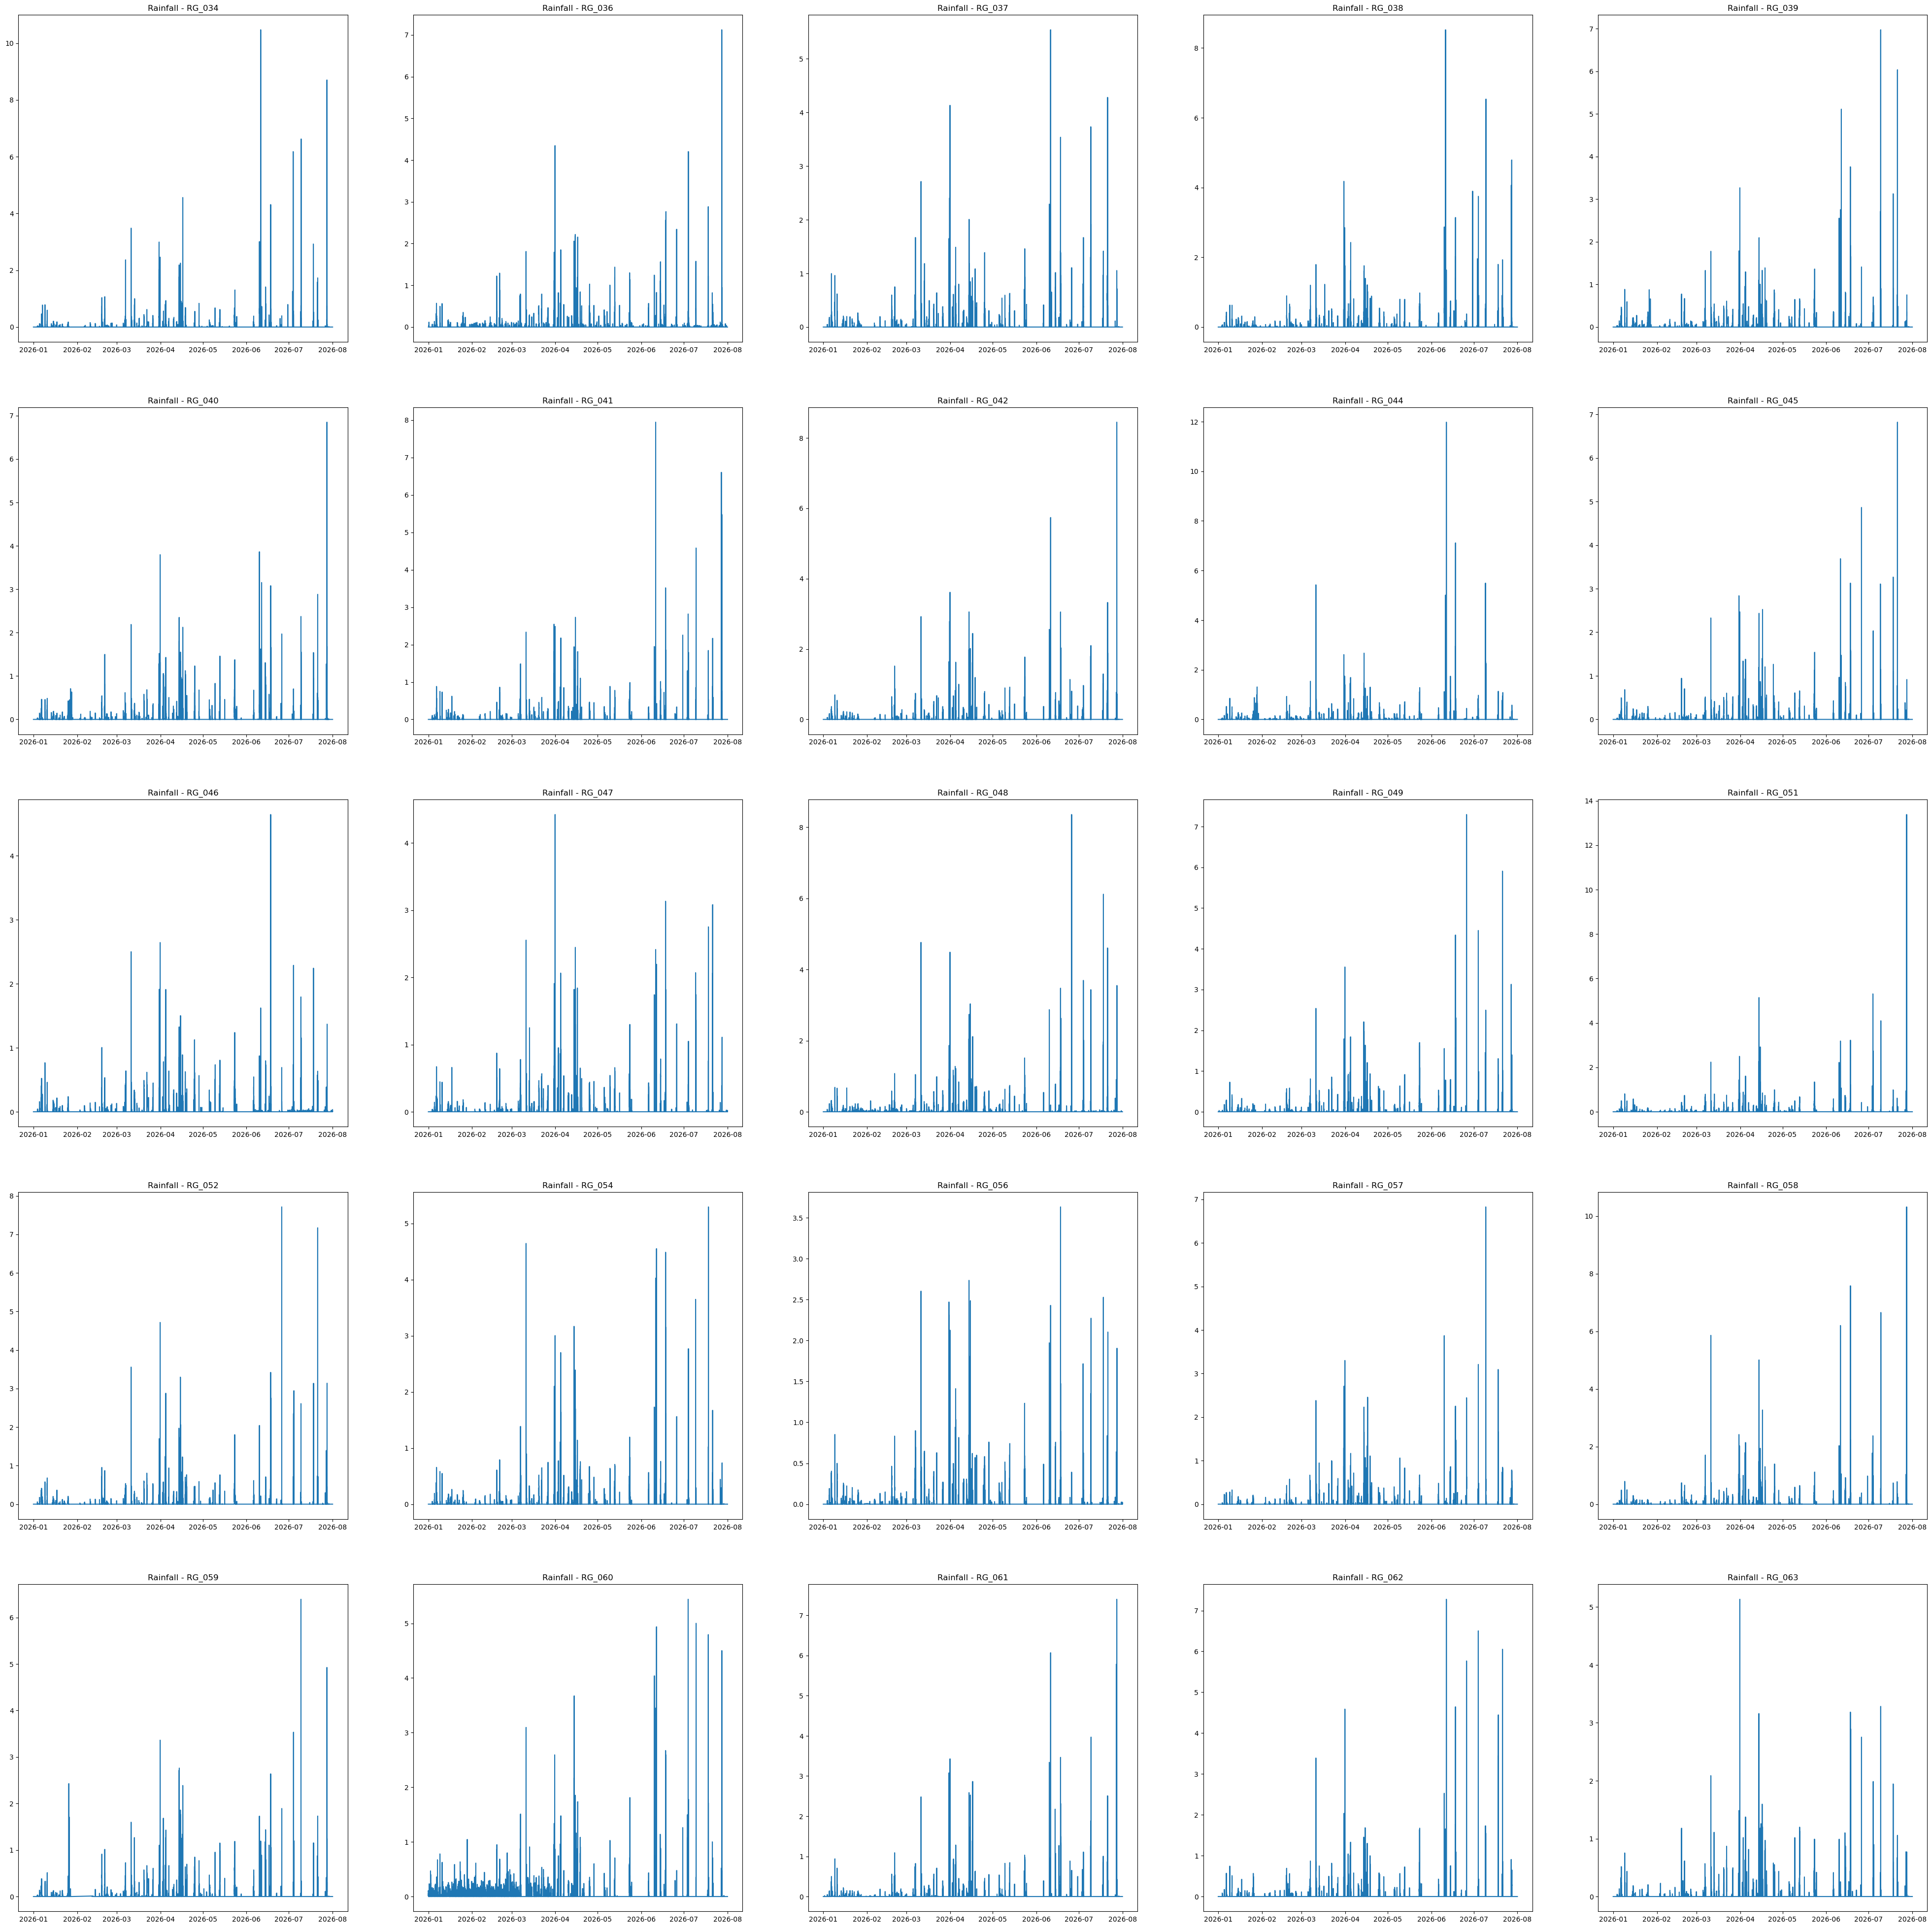

In [19]:
unique = data['name'].unique()
fig, ax1 = plt.subplots(nrows=5, ncols=5, figsize=(50, 50));
fig, ax2 = plt.subplots(nrows=5, ncols=5, figsize=(50, 50));
for i in range(5):
    for j in range(5):
        ax1[i][j].plot(station_data[unique[5*i + j]][0]['date'], station_data[unique[5*i + j]][0]['rainfall']);
        ax1[i][j].set_title("Rainfall - {}".format(unique[5*i + j]))
        ax2[5-i-1][5-j-1].plot(station_data[unique[48 - (5*i + j)]][0]['date'], station_data[unique[48 - (5*i + j)]][0]['rainfall']);
        ax2[5-i-1][5-j-1].set_title("Rainfall - {}".format(unique[48 - (5*i + j)]))

print(ax1);
print(ax2);

In [20]:
import numpy as np
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import BayesianRidge
from sklearn.tree import DecisionTreeRegressor

dtr = DecisionTreeRegressor()

for station in data['name'].unique():
    train = station_data[station][0]
    test = station_data[station][1]

    dtr.fit(np.arange(train['date'].size).reshape(-1, 1), train['rainfall'])

    dtr_pred = dtr.predict(np.arange(test['date'].size).reshape(-1, 1))

    station_data[station].extend([dtr_pred])

print(station_data["RG_003"][2])


[0. 0. 0. ... 0. 0. 0.]


[[<Axes: title={'center': 'Rainfall - RG_001'}>
  <Axes: title={'center': 'Rainfall - RG_003'}>
  <Axes: title={'center': 'Rainfall - RG_004'}>
  <Axes: title={'center': 'Rainfall - RG_006'}>
  <Axes: title={'center': 'Rainfall - RG_007'}>]
 [<Axes: title={'center': 'Rainfall - RG_012'}>
  <Axes: title={'center': 'Rainfall - RG_013'}>
  <Axes: title={'center': 'Rainfall - RG_014'}>
  <Axes: title={'center': 'Rainfall - RG_015'}>
  <Axes: title={'center': 'Rainfall - RG_016'}>]
 [<Axes: title={'center': 'Rainfall - RG_017'}>
  <Axes: title={'center': 'Rainfall - RG_018'}>
  <Axes: title={'center': 'Rainfall - RG_019'}>
  <Axes: title={'center': 'Rainfall - RG_020'}>
  <Axes: title={'center': 'Rainfall - RG_021'}>]
 [<Axes: title={'center': 'Rainfall - RG_022'}>
  <Axes: title={'center': 'Rainfall - RG_023'}>
  <Axes: title={'center': 'Rainfall - RG_024'}>
  <Axes: title={'center': 'Rainfall - RG_025'}>
  <Axes: title={'center': 'Rainfall - RG_027'}>]
 [<Axes: title={'center': 'Rainfall 

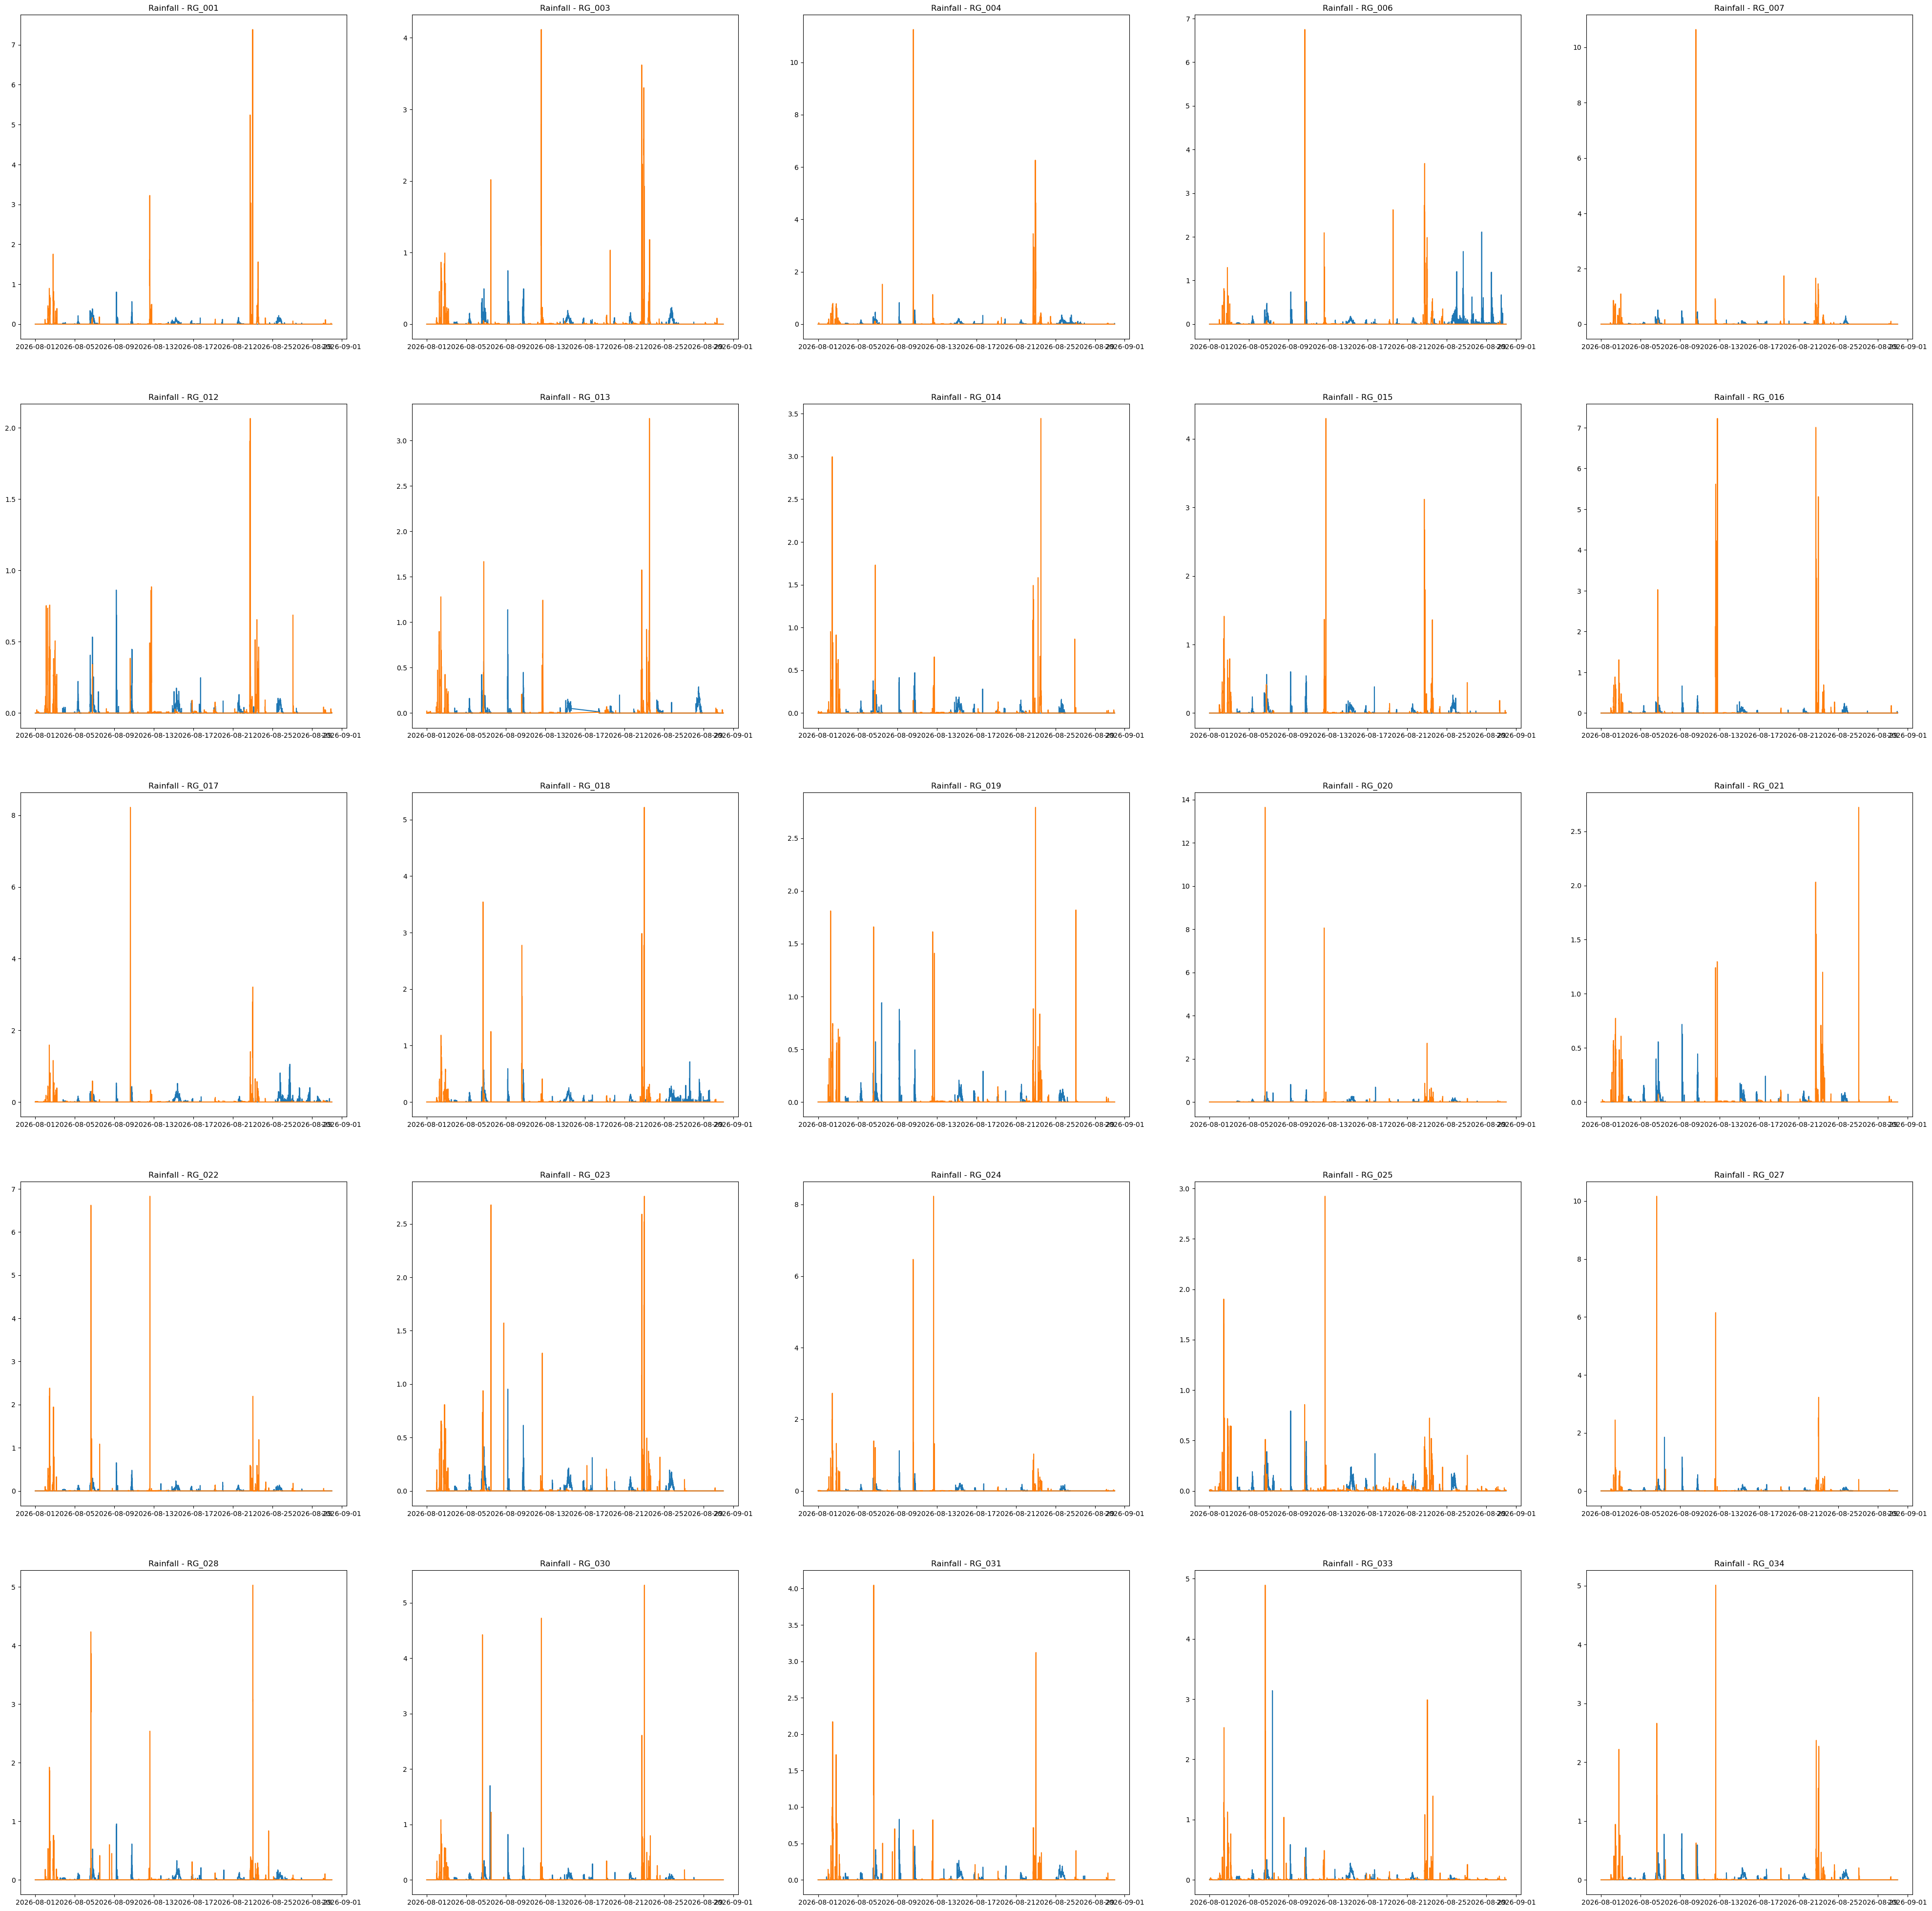

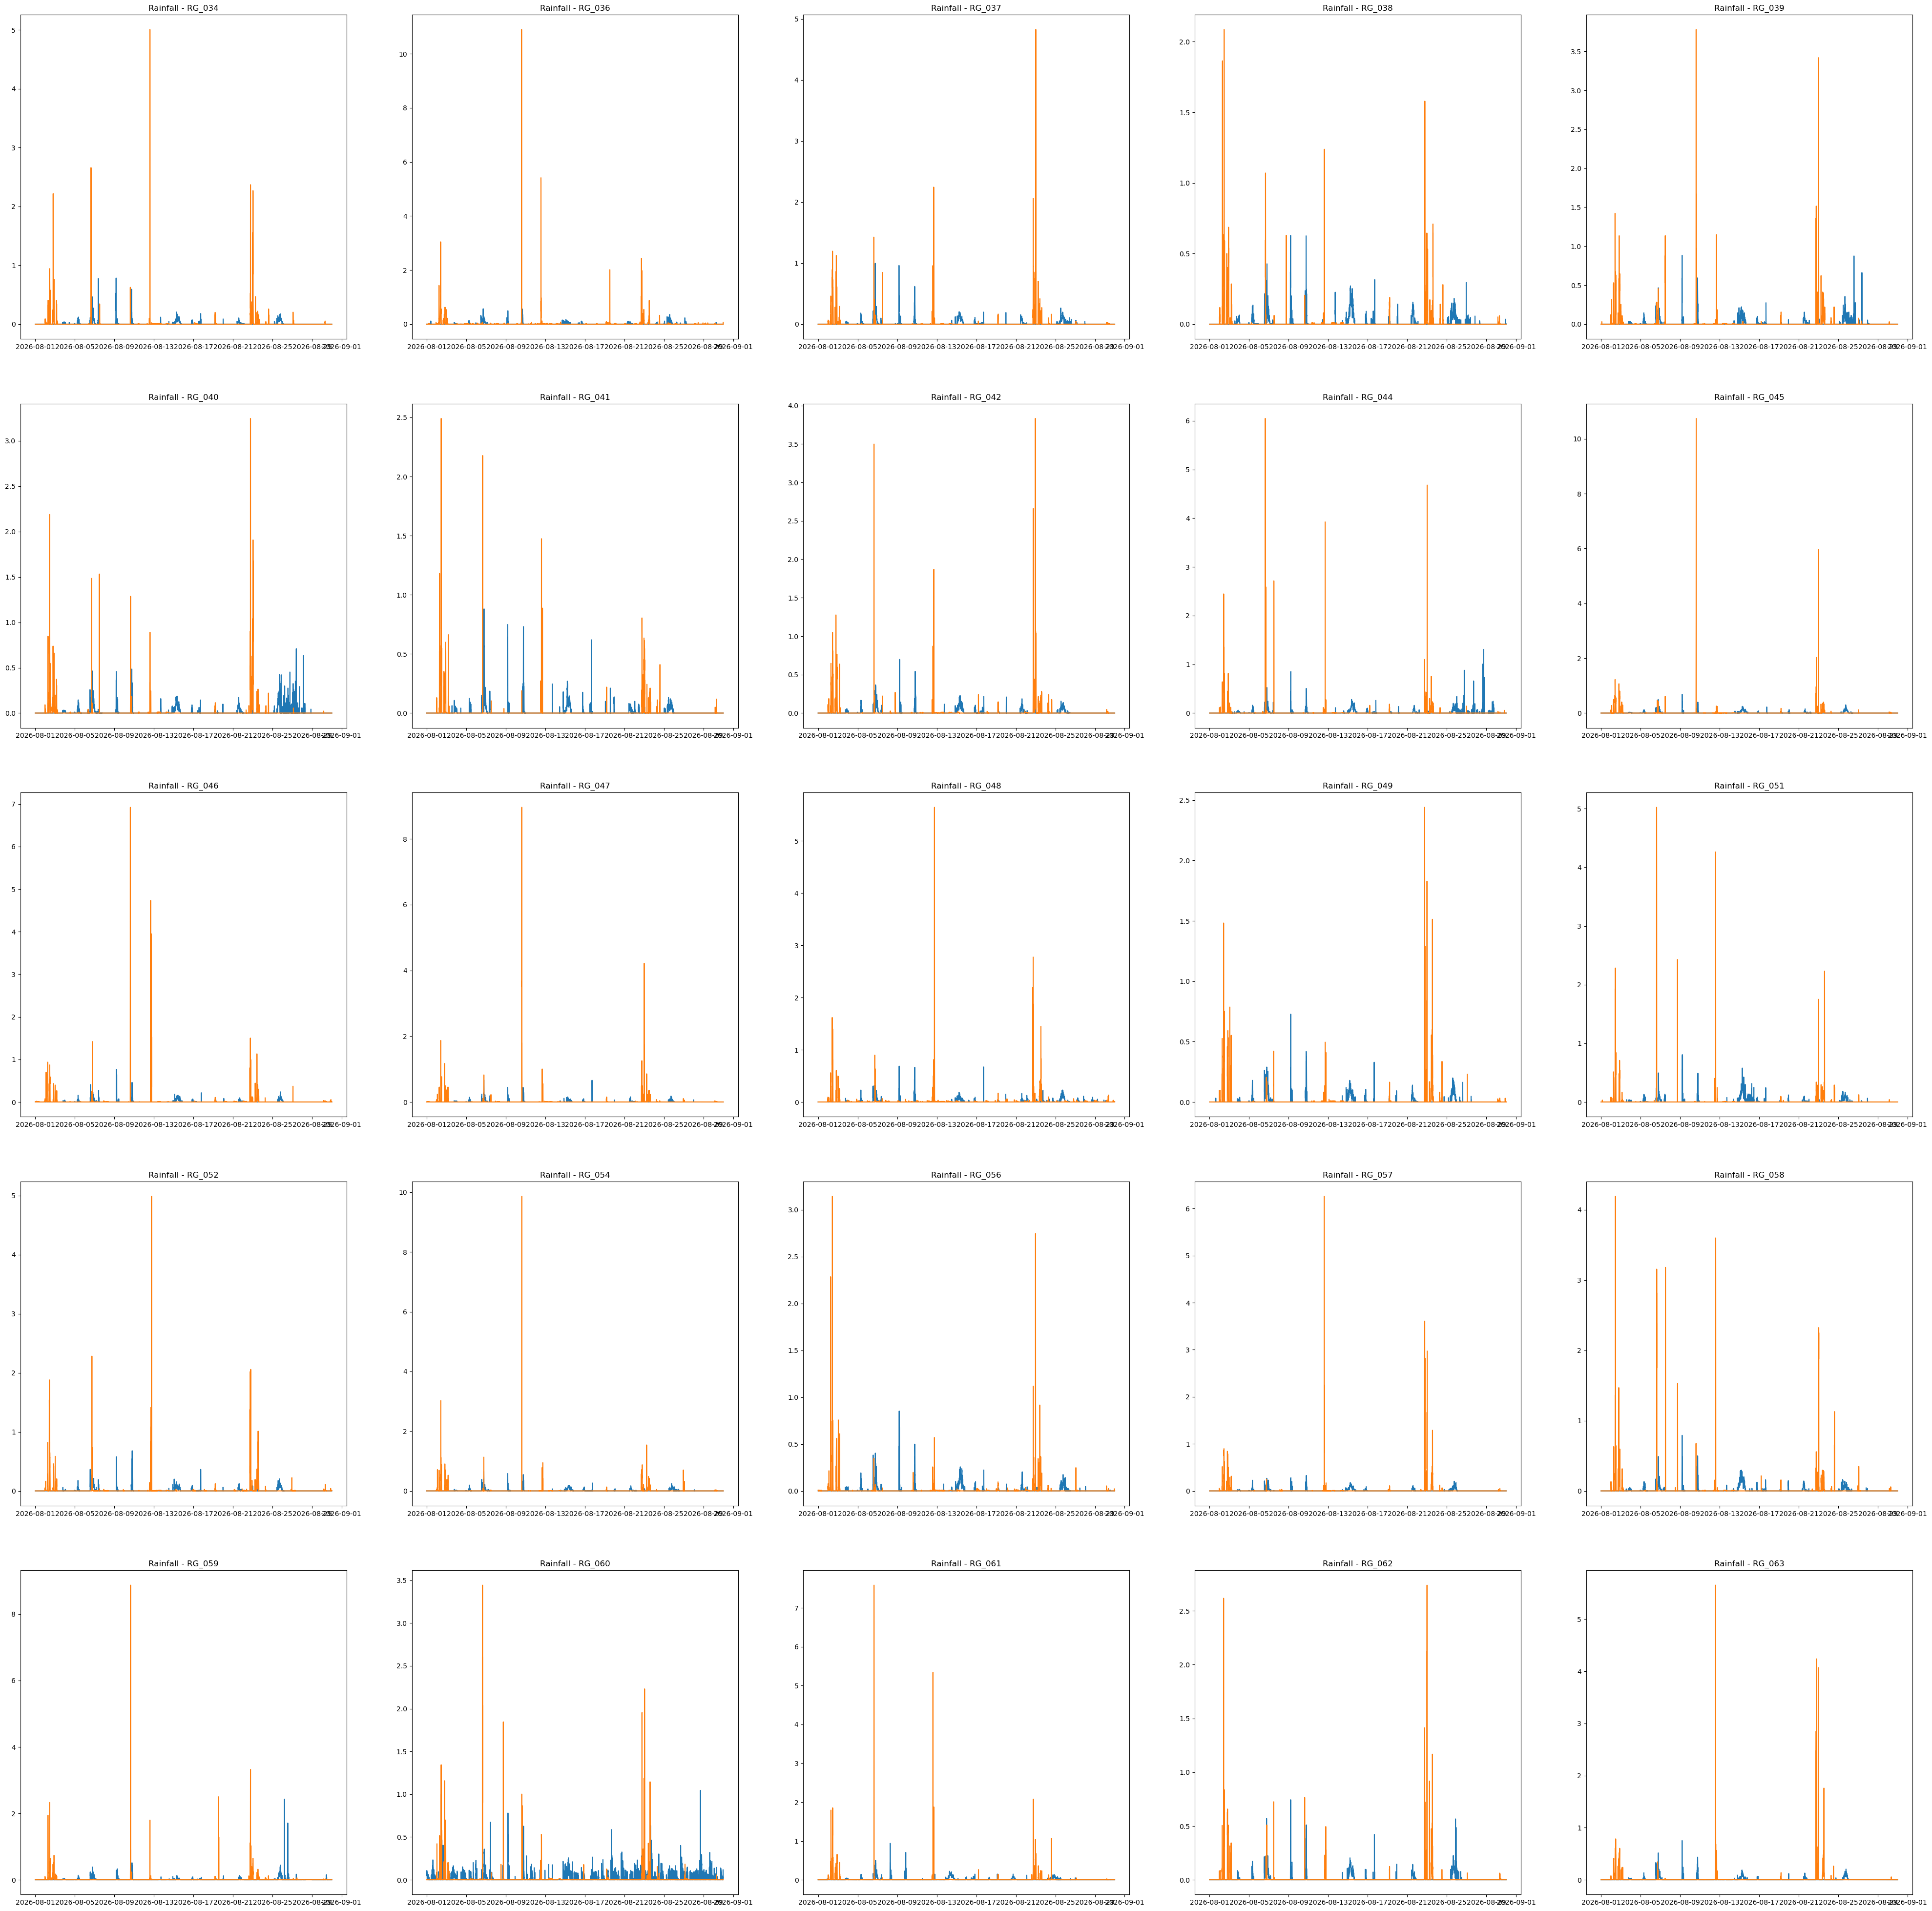

In [24]:
unique = data['name'].unique()
fig, ax1 = plt.subplots(nrows=5, ncols=5, figsize=(50, 50));
fig, ax2 = plt.subplots(nrows=5, ncols=5, figsize=(50, 50));
for i in range(5):
    for j in range(5):
        test_1, test_2 = station_data[unique[5*i + j]], station_data[unique[48 - (5*i + j)]]
        ax1[i][j].plot(test_1[1]['date'], test_1[2]);
        ax1[i][j].plot(test_1[1]['date'], test_1[1]['rainfall']);
        ax1[i][j].set_title("Rainfall - {}".format(unique[5*i + j]))
        ax2[5-i-1][5-j-1].plot(test_2[1]['date'], test_2[2]);
        ax2[5-i-1][5-j-1].plot(test_2[1]['date'], test_2[1]['rainfall']);
        ax2[5-i-1][5-j-1].set_title("Rainfall - {}".format(unique[48 - (5*i + j)]))

print(ax1);
print(ax2);